# 实验 20：基于 Transformer 的中英机器翻译

**实验性质**：设计性实验 (Design Experiment)  
**核心模型**：Transformer (Seq2Seq Architecture)  
**技术点**：Self-Attention, Positional Encoding, Masking  
**数据集**：ManyThings/Tatoeba (English-Chinese)

## 1. 实验背景与意义

### 知识点简述
传统的机器翻译模型（如 RNN/LSTM）在处理长序列时存在“遗忘”问题，且无法并行计算。2017 年 Google 提出的 **Transformer** 架构完全抛弃了循环结构，完全基于 **注意力机制 (Attention Mechanism)**。
* **Self-Attention**：让模型在处理某个词时，能关注到句子中其他位置相关的词。
* **Positional Encoding**：由于没有了循环结构，必须显式地注入位置信息，让模型知道词序。

### 设计意义
本实验不直接调用 `HuggingFace` 的预训练模型（如 BERT/GPT），而是利用 PyTorch 的基础组件搭建一个微型的 Transformer。
学生将通过本实验掌握：
1.  **数据流水线**：如何构建源语言和目标语言的词表 (Vocabulary) 及数据批处理 (Batching)。
2.  **掩码机制 (Masking)**：理解 Padding Mask（忽略填充符）和 Look-ahead Mask（防止看见未来答案）的区别。
3.  **模型构建**：亲手组装 Embedding、PositionalEncoding 和 Transformer 模块。


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import math
import random
import numpy as np
import jieba # 用于中文分词
from collections import Counter
from tqdm import tqdm

# 设置随机种子，保证实验可复现
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'当前使用的计算设备: {device}')


当前使用的计算设备: cuda


d:\conda\miniconda\envs\project1\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
import requests
import zipfile

# ================= 路径配置 (关键修改) =================
# ".." 表示上一级目录，从 nootbook 文件夹跳出去，再进入 data 文件夹
DATA_DIR = os.path.join('..', 'data') 

# 确保 data 目录存在，如果不存在代码会自动创建，防止报错
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

# 定义完整的文件路径
TXT_PATH = os.path.join(DATA_DIR, 'cmn.txt')
ZIP_PATH = os.path.join(DATA_DIR, 'cmn-eng.zip')
DATA_URL = 'http://www.manythings.org/anki/cmn-eng.zip'

# 为了让后面的代码能直接用，我们将最终的 txt 路径赋值给 FILE_NAME
FILE_NAME = TXT_PATH 
# ======================================================

def prepare_dataset():
    # 1. 判断 txt 是否已经存在 (最高优先级)
    if os.path.exists(TXT_PATH):
        print(f' 数据文件已就绪: {TXT_PATH}')
        return

    # 2. 判断 zip 是否存在 (如果 txt 不在，但 zip 在)
    if not os.path.exists(ZIP_PATH):
        print(f'本地未找到压缩包，正在下载到: {ZIP_PATH} ...')
        try:
            r = requests.get(DATA_URL)
            with open(ZIP_PATH, 'wb') as f:
                f.write(r.content)
            print('下载完成。')
        except Exception as e:
            print(f' 下载失败: {e}')
            print('请检查网络，或手动将 cmn-eng.zip 放入 ../data/ 目录')
            return
    else:
        print(f'检测到本地压缩包: {ZIP_PATH}')

    # 3. 解压逻辑 (解压到 data 目录，而不是当前目录)
    print('正在解压...')
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            # extractall 的路径设为 DATA_DIR，这样解压出来的文件会在 data 文件夹里
            zip_ref.extractall(DATA_DIR) 
        print(f' 解压完毕！文件位置: {TXT_PATH}')
    except Exception as e:
        print(f' 解压失败: {e}')

# --- 执行准备工作 ---
prepare_dataset()

# --- 验证读取 (使用 FILE_NAME 变量) ---
if os.path.exists(FILE_NAME):
    print("-" * 30)
    print(f"正在读取文件: {os.path.abspath(FILE_NAME)}")
    print("前 5 行预览:")
    with open(FILE_NAME, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[:5]:
            print(line.strip())
    print("-" * 30)

 数据文件已就绪: ..\data\cmn.txt
------------------------------
正在读取文件: d:\project2\26--Transformer\data\cmn.txt
前 5 行预览:
Hi.	嗨。	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)
Hi.	你好。	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #4857568 (musclegirlxyp)
Run.	你用跑的。	CC-BY 2.0 (France) Attribution: tatoeba.org #4008918 (JSakuragi) & #3748344 (egg0073)
Stay.	待著。	CC-BY 2.0 (France) Attribution: tatoeba.org #8907595 (CK) & #13109376 (LeviHighway)
Stay.	且慢。	CC-BY 2.0 (France) Attribution: tatoeba.org #8907595 (CK) & #13138846 (LeviHighway)
------------------------------


## 2. 数据预处理与词表构建
我们需要定义特殊的 Token：`<sos>` (Start of Sentence), `<eos>` (End of Sentence), `<pad>` (Padding), `<unk>` (Unknown)。并将英文按空格分词，中文使用 `jieba` 分词。


In [3]:
# 定义特殊符号
SOS_token = 0  # Start of Sentence
EOS_token = 1  # End of Sentence
PAD_token = 2  # Padding
UNK_token = 3  # Unknown word

class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2index = {'<sos>': 0, '<eos>': 1, '<pad>': 2, '<unk>': 3}
        self.word2count = {}
        self.index2word = {0: '<sos>', 1: '<eos>', 2: '<pad>', 3: '<unk>'}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence:
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# 数据清洗与加载函数
def prepare_data(filepath, max_len=20, max_samples=10000):
    pairs = []
    if not os.path.exists(filepath):
        print('未找到数据文件，跳过数据加载。')
        return None, None, []

    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 为了演示快速训练，我们只取较短的句子和部分样本
    count = 0
    for line in lines:
        if count >= max_samples: break
        parts = line.strip().split('\t')
        if len(parts) < 2: continue
        
        eng_sent = parts[0].lower().strip().replace('.', '').replace('!', '').replace('?', '')
        chn_sent = parts[1].strip()
        
        # 分词
        eng_tokens = eng_sent.split(' ')
        chn_tokens = list(jieba.cut(chn_sent)) # 中文分词
        
        if len(eng_tokens) <= max_len and len(chn_tokens) <= max_len:
            pairs.append((eng_tokens, chn_tokens))
            count += 1
            
    input_vocab = Vocab('English')
    output_vocab = Vocab('Chinese')
    
    for pair in pairs:
        input_vocab.add_sentence(pair[0])
        output_vocab.add_sentence(pair[1])
        
    print(f'读取样本数: {len(pairs)}')
    print(f'英文词汇量: {input_vocab.n_words}')
    print(f'中文词汇量: {output_vocab.n_words}')
    return input_vocab, output_vocab, pairs

input_vocab, output_vocab, pairs = prepare_data(FILE_NAME)

# 打印一组处理后的数据
if pairs:
    print(f'示例: {pairs[100]}')


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\86177\AppData\Local\Temp\jieba.cache
Loading model cost 0.513 seconds.
Prefix dict has been built successfully.


读取样本数: 10000
英文词汇量: 3256
中文词汇量: 5779
示例: (['dress', 'up'], ['穿', '上', '衣服', '。'])


In [4]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, input_vocab, output_vocab):
        self.pairs = pairs
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tokens, tgt_tokens = self.pairs[idx]
        # 将单词转换为索引
        src_indices = [self.input_vocab.word2index.get(token, UNK_token) for token in src_tokens]
        tgt_indices = [self.output_vocab.word2index.get(token, UNK_token) for token in tgt_tokens]
        
        # 加上开始和结束符
        src_indices = [SOS_token] + src_indices + [EOS_token]
        tgt_indices = [SOS_token] + tgt_indices + [EOS_token]
        
        return torch.tensor(src_indices), torch.tensor(tgt_indices)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    # 填充序列
    src_batch = pad_sequence(src_batch, padding_value=PAD_token, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_token, batch_first=True)
    return src_batch, tgt_batch

if pairs:
    dataset = TranslationDataset(pairs, input_vocab, output_vocab)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

    # 测试一下 DataLoader
    src_sample, tgt_sample = next(iter(dataloader))
    print(f'Source Batch Shape: {src_sample.shape}') # [Batch, Seq_Len]
    print(f'Target Batch Shape: {tgt_sample.shape}')


Source Batch Shape: torch.Size([32, 8])
Target Batch Shape: torch.Size([32, 10])


## 3. 位置编码 (Positional Encoding)
Transformer 没有循环结构（如 RNN），输入 "Tom hit Jerry" 和 "Jerry hit Tom" 对模型来说如果不加位置信息是一样的。我们需要叠加正弦/余弦波来注入位置信息。


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # 创建一个矩阵 [max_len, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 增加一个维度 [1, max_len, d_model] 以便广播
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # 加上位置编码
        x = x + self.pe[:, :x.size(1), :]
        return x


## 4. Transformer 模型构建

**核心设计**：
1.  **Masking**: `tgt_mask` 是为了防止解码时看到“未来”的词（因果遮罩）。`src_key_padding_mask` 是为了让 Attention 机制忽略填充的 0 (PAD)。
2.  利用 PyTorch 内置的 `nn.Transformer` 简化实现。


In [6]:
class TransformerModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=4, 
                 num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512, dropout=0.1):
        super(TransformerModel, self).__init__()
        
        self.d_model = d_model
        
        # 词嵌入层
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        
        # 位置编码
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer 核心模块
        # batch_first=True 表示输入格式为 [batch, seq_len, embedding]
        self.transformer = nn.Transformer(d_model=d_model, nhead=nhead, 
                                          num_encoder_layers=num_encoder_layers,
                                          num_decoder_layers=num_decoder_layers,
                                          dim_feedforward=dim_feedforward,
                                          dropout=dropout,
                                          batch_first=True)
        
        # 输出层
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt):
        # src: [batch, src_len]
        # tgt: [batch, tgt_len]
        
        # 生成 Mask
        # 1. Target 的掩码 (防止看到未来) - 上三角矩阵
        tgt_seq_len = tgt.size(1)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_seq_len).to(device)
        
        # 2. Padding Mask (忽略 PAD 的位置)
        # src_key_padding_mask: [batch, src_len] -> True 表示该位置是 PAD
        src_padding_mask = (src == PAD_token).to(device)
        tgt_padding_mask = (tgt == PAD_token).to(device)
        
        # Embedding + Positional Encoding
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        
        # Transformer 前向传播
        output = self.transformer(src=src_emb, tgt=tgt_emb, 
                                  tgt_mask=tgt_mask, 
                                  src_key_padding_mask=src_padding_mask,
                                  tgt_key_padding_mask=tgt_padding_mask,
                                  memory_key_padding_mask=src_padding_mask)
        
        return self.fc_out(output)


Epoch 1/15:   0%|          | 0/313 [00:00<?, ?it/s]d:\conda\miniconda\envs\project1\lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Epoch 1/15: 100%|██████████| 313/313 [00:14<00:00, 21.54it/s, loss=4.65]


Epoch 1 -> Loss: 4.4163 | Acc: 0.4004


Epoch 2/15: 100%|██████████| 313/313 [00:13<00:00, 22.83it/s, loss=3.56]


Epoch 2 -> Loss: 3.5083 | Acc: 0.4732


Epoch 3/15: 100%|██████████| 313/313 [00:13<00:00, 22.90it/s, loss=2.88]


...

Epoch 13 -> Loss: 0.6707 | Acc: 0.8155


Epoch 14/15: 100%|██████████| 313/313 [00:13<00:00, 23.02it/s, loss=0.533]


Epoch 14 -> Loss: 0.6136 | Acc: 0.8255


Epoch 15/15: 100%|██████████| 313/313 [00:13<00:00, 23.01it/s, loss=0.584]


Epoch 15 -> Loss: 0.5768 | Acc: 0.8343


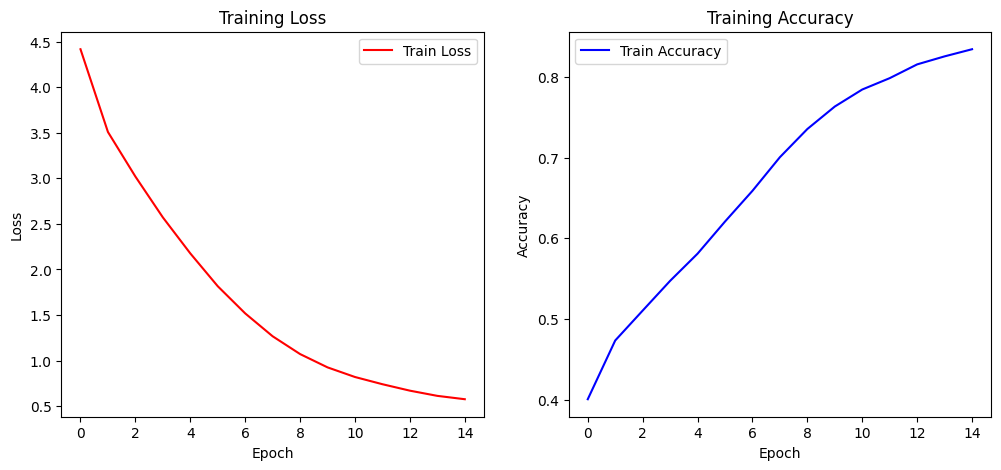

In [7]:
model = TransformerModel(input_vocab.n_words, output_vocab.n_words).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

# 记录历史数据
history = {'loss': [], 'acc': []}

def train(epochs=15):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        total_correct = 0
        total_tokens = 0
        
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for src, tgt in pbar:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            
            optimizer.zero_grad()
            output = model(src, tgt_in)
            
            # 计算 Loss
            loss = criterion(output.reshape(-1, output.shape[-1]), tgt_out.reshape(-1))
            loss.backward()
            optimizer.step()
            
            # 计算 Accuracy (Token级别)
            preds = output.argmax(dim=-1)
            mask = (tgt_out != PAD_token)
            correct = (preds == tgt_out) & mask
            total_correct += correct.sum().item()
            total_tokens += mask.sum().item()
            total_loss += loss.item()
            
            pbar.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_correct / total_tokens
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        print(f'Epoch {epoch+1} -> Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}')

train(epochs=15)

# 绘制曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 5. 翻译测试

In [8]:
## 6. 推理与翻译

def translate_sentence(model, sentence, input_vocab, output_vocab, max_length=20):
    model.eval()
    
    # 预处理输入句子
    sentence = sentence.lower().replace('.', '').replace('!', '').replace('?', '')
    tokens = sentence.split(' ')
    indices = [input_vocab.word2index.get(token, UNK_token) for token in tokens]
    
    # 加上起始和结束符
    indices = [SOS_token] + indices + [EOS_token]
    src_tensor = torch.tensor(indices).unsqueeze(0).to(device) # [1, seq_len]
    
    # 初始 Decoder 输入只有 <sos>
    tgt_indices = [SOS_token]
    
    with torch.no_grad():
        for i in range(max_length):
            tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)
            
            # 预测
            output = model(src_tensor, tgt_tensor)
            
            # 获取最后一个时间步的预测结果
            pred_token = output[0, -1, :].argmax().item()
            
            if pred_token == EOS_token:
                break
                
            tgt_indices.append(pred_token)
            
    translated_tokens = [output_vocab.index2word[i] for i in tgt_indices[1:]]
    return ''.join(translated_tokens)

# 测试几个句子
if 'pairs' in globals() and pairs: # 确保数据已加载
    test_sentences = [
        'What is your name',
        'He is a good man',
        'Where are you going'
    ]

    print('--- 翻译结果 ---')
    for s in test_sentences:
        trans = translate_sentence(model, s, input_vocab, output_vocab)
        print(f'英文: {s} -> 中文: {trans}')

--- 翻译结果 ---


d:\conda\miniconda\envs\project1\lib\site-packages\torch\nn\modules\transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(


英文: What is your name -> 中文: 你叫什么名字？
英文: He is a good man -> 中文: 他是个不错的人。
英文: Where are you going -> 中文: 你去哪裡？


### 6. 学生拓展与思考 (Extensions & Reflection)

1.  **关于 Masking**：在 `TransformerModel` 的 `forward` 函数中，我们使用了 `tgt_mask` (Target Mask)。如果去掉这个 Mask，会发生什么？
2.  **关于位置编码**：本实验使用了正弦余弦函数生成位置编码。如果将其改为可学习的参数（`nn.Parameter`），效果会有区别吗？
3.  **注意力可视化**：尝试修改代码，提取出 `self.transformer` 中的 Attention Weights，并画出热力图。


## 6. 学生拓展与思考 (Extensions & Reflection)

请结合实验代码与理论知识，思考以下问题。**点击问题标题即可查看参考答案**。

---

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px; color: #2980b9;">
     问题 1: 关于 Masking (Target Mask) 的作用
</summary>
<div style="background-color: #f0f7fb; padding: 15px; border-left: 5px solid #3498db; margin-top: 10px; border-radius: 4px;">
    <p><strong>核心答案： (Data Leakage)。</strong></p>
    <p>Transformer 在训练时是并行的（Teacher Forcing），即一次性把整个目标句子输入给 Decoder。</p>
    <ul>
        <li><strong>如果没有 Mask</strong>：在预测第 $i$ 个词时，Self-Attention 机制可以看到第 $i+1$ 甚至后面的所有词（真实答案）。模型会直接“抄袭”答案，而不是学习语言逻辑。</li>
        <li><strong>后果</strong>：训练 Loss 会瞬间降到接近 0，但在测试（推理）阶段，因为没有未来信息，模型会完全失效。</li>
    </ul>
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px; color: #27ae60;">
     问题 2: 正弦位置编码 vs 可学习参数 (nn.Parameter)
</summary>
<div style="background-color: #f0fdf4; padding: 15px; border-left: 5px solid #2ecc71; margin-top: 10px; border-radius: 4px;">
    <p><strong>核心答案：正弦编码具有更好的“外推性” (Extrapolation)。</strong></p>
    <ul>
        <li><strong>可学习参数 (Learned Embedding)</strong>：类似于词向量。如果训练集最长句子是 50，模型就没有位置 51 的参数。遇到更长的句子时直接报错或失效。</li>
        <li><strong>正弦/余弦函数 (Sinusoidal)</strong>：基于数学公式生成。即使训练时只见过长度 50 的句子，公式依然可以计算出位置 100 的编码。理论上它可以处理比训练集更长的序列。</li>
    </ul>
    <p><em>注：在 BERT 等现代模型中，为了简单通常使用可学习参数，因为大多数任务都有最大长度限制（如 512）。</em></p>
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px; color: #c0392b;">
     问题 3: 如何提取并可视化 Attention 权重？
</summary>
<div style="background-color: #fdf2f0; padding: 15px; border-left: 5px solid #e74c3c; margin-top: 10px; border-radius: 4px;">
    <p><strong>解答思路：</strong></p>
    <p>由于 PyTorch 的 <code>nn.Transformer</code> 封装程度很高，直接提取权重比较困难。通常有两种方法：</p>
    <ol>
        <li><strong>使用 Hook (推荐)</strong>：正如本实验代码所示，利用 <code>register_forward_hook</code> 挂载到 <code>transformer.decoder.layers[-1].multihead_attn</code> 上，拦截前向传播时的 output。</li>
        <li><strong>手动实现层</strong>：不使用 <code>nn.Transformer</code> 整体模块，而是自己用 <code>nn.MultiheadAttention</code> 一层层搭建，这样可以在 forward 时设置 <code>need_weights=True</code> 来直接获取返回值。</li>
    </ol>
    <p><strong>预期结果</strong>：对于翻译任务，好的 Attention 热力图通常呈现<strong>对角线</strong>分布（因为中英文语序大体一致）。</p>
</div>
</details>
